Shape: (2000, 21)

Columns:
['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range']

First 5 rows:
   battery_power      blue  clock_speed  dual_sim        fc    four_g  \
0      -0.902597 -0.990050     0.830779 -1.019184 -0.762495 -1.043966   
1      -0.495139  1.010051    -1.253064  0.981177 -0.992890  0.957886   
2      -1.537686  1.010051    -1.253064  0.981177 -0.532099  0.957886   
3      -1.419319  1.010051     1.198517 -1.019184 -0.992890 -1.043966   
4       1.325906  1.010051    -0.395011 -1.019184  2.002254  0.957886   

   int_memory     m_dep  mobile_wt   n_cores  ...  px_height  px_width  \
0   -1.380644  0.340740   1.349249 -1.101971  ...  -1.411690 -1.146784   
1    1.155024  0.687548  -0.120059 -0.664768  ...   0.585116  1.704465   
2    0.493546  1.381165   0.134244  0.209639  ...   1.392864  1

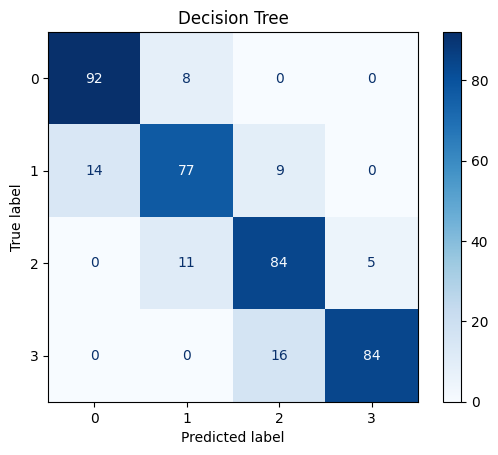


===== KNN =====
Confusion Matrix:
[[71 25  4  0]
 [33 43 19  5]
 [ 5 38 43 14]
 [ 0  8 41 51]]
Accuracy : 0.52
Precision: 0.5397524291737661
Recall   : 0.52
F1-Score : 0.5241884833492866


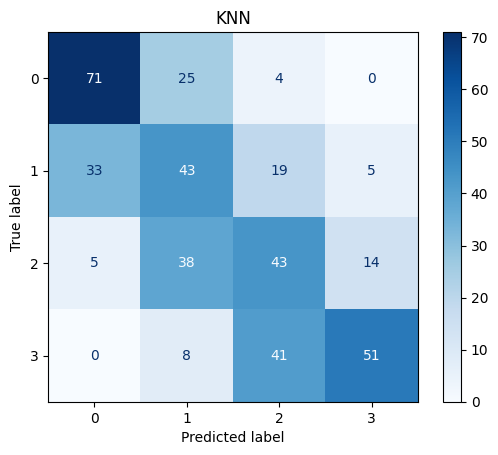


===== Naive Bayes =====
Confusion Matrix:
[[90 10  0  0]
 [ 7 69 24  0]
 [ 0 18 73  9]
 [ 0  0  8 92]]
Accuracy : 0.81
Precision: 0.8113261105197412
Recall   : 0.81
F1-Score : 0.8104578013732255


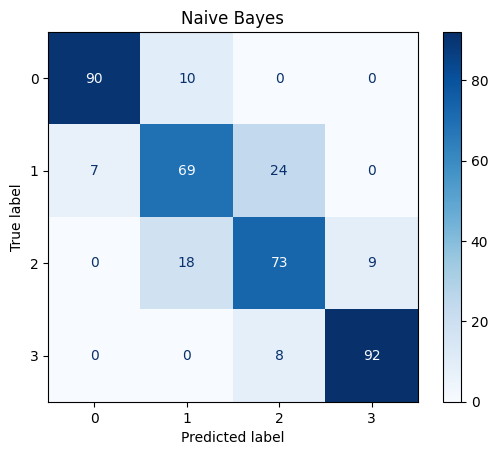


Final Comparison:
           Model  Accuracy  Precision  Recall  F1-Score
0  Decision Tree    0.8425   0.846118  0.8425  0.842909
1    Naive Bayes    0.8100   0.811326  0.8100  0.810458
2            KNN    0.5200   0.539752  0.5200  0.524188

Best Model: Decision Tree
Best Accuracy: 0.8425


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


file_path = "../data/mobile_price_classification.csv"
target_col = "price_range"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ===================================================================================
def evaluate_model(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n===== {model_name} =====")
    print("Confusion Matrix:")
    print(cm)
    print("Accuracy :", acc)
    print("Precision:", pre)
    print("Recall   :", rec)
    print("F1-Score :", f1)

    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
    plt.title(model_name)
    plt.show()

    return acc, pre, rec, f1
# ===================================================================================


# decision tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc, dt_pre, dt_rec, dt_f1 = evaluate_model("Decision Tree", y_test, dt_pred)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_acc, knn_pre, knn_rec, knn_f1 = evaluate_model("KNN", y_test, knn_pred)


# naive bayes
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
nb_pred = nb.predict(X_test_scaled)
nb_acc, nb_pre, nb_rec, nb_f1 = evaluate_model("Naive Bayes", y_test, nb_pred)


# results models
results = pd.DataFrame({
    "Model": ["Decision Tree", "KNN", "Naive Bayes"],
    "Accuracy": [dt_acc, knn_acc, nb_acc],
    "Precision": [dt_pre, knn_pre, nb_pre],
    "Recall": [dt_rec, knn_rec, nb_rec],
    "F1-Score": [dt_f1, knn_f1, nb_f1]
})

best_model = results.iloc[results["Accuracy"].idxmax()]
print("\nBest Model:", best_model["Model"])
print("Best Accuracy:", best_model["Accuracy"])